In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
ark = pd.read_csv("ai4i2020.csv")


In [3]:
df = ark.copy()

In [4]:
missing_values = df.isnull().sum()
print(missing_values)

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


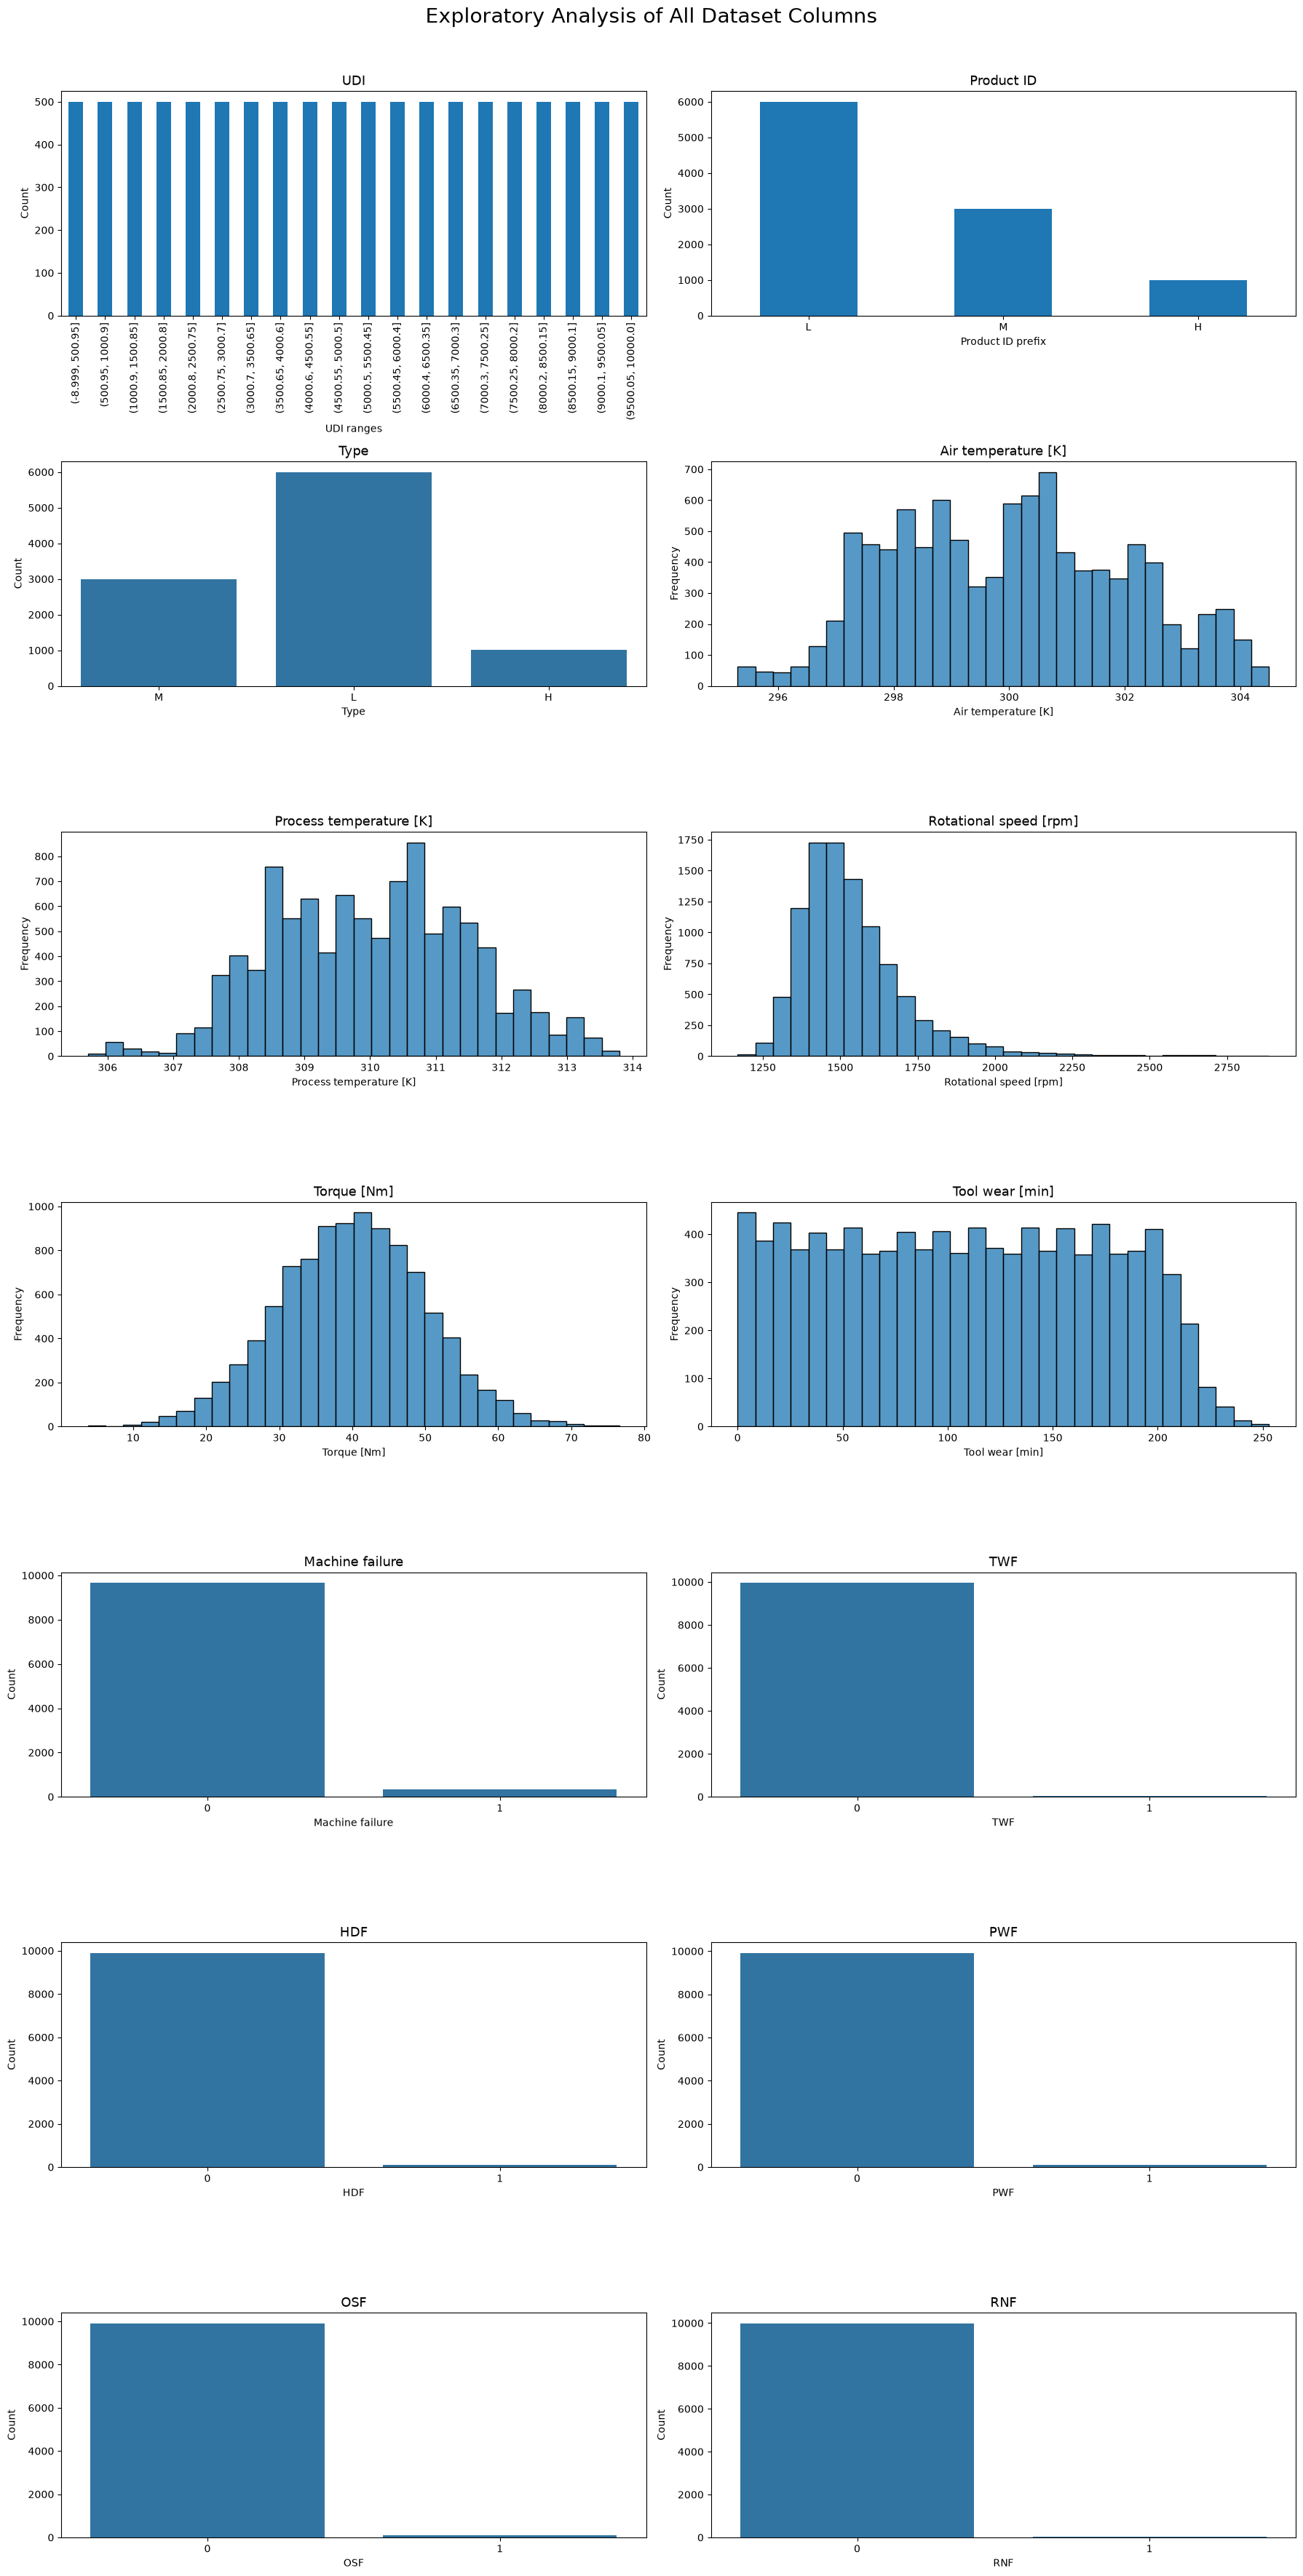

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



columns = [
    "UDI",
    "Product ID",
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

# Columns containing categories
categorical_columns = [
    "Type",
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

# Columns containing continuous numbers
numerical_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

# Create 7 rows and 2 columns of subplots
fig, axes = plt.subplots(7, 2, figsize=(18, 35))

# Convert 2D axes into a 1D list
axes = axes.flatten()

for index, column in enumerate(columns):

    ax = axes[index]

    # Plot categorical and binary columns
    if column in categorical_columns:

        sns.countplot(
            data=df,
            x=column,
            ax=ax
        )

        ax.set_ylabel("Count")

    # Plot continuous numerical columns
    elif column in numerical_columns:

        sns.histplot(
            data=df,
            x=column,
            bins=30,
            ax=ax
        )

        ax.set_ylabel("Frequency")

    # UDI contains 10,000 unique numbers
    elif column == "UDI":

        # Divide UDI into groups instead of plotting all 10,000 values
        udi_groups = pd.cut(df["UDI"], bins=20)

        udi_counts = udi_groups.value_counts().sort_index()

        udi_counts.plot(
            kind="bar",
            ax=ax
        )

        ax.set_xlabel("UDI ranges")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=90)

    # Product ID is almost unique, so show only product prefixes
    elif column == "Product ID":

        product_prefix = df["Product ID"].str[0].value_counts()

        product_prefix.plot(
            kind="bar",
            ax=ax
        )

        ax.set_xlabel("Product ID prefix")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=0)

    ax.set_title(column, fontsize=13)

plt.suptitle(
    "Exploratory Analysis of All Dataset Columns",
    fontsize=20,
    y=1.01
)

plt.tight_layout()
plt.show()

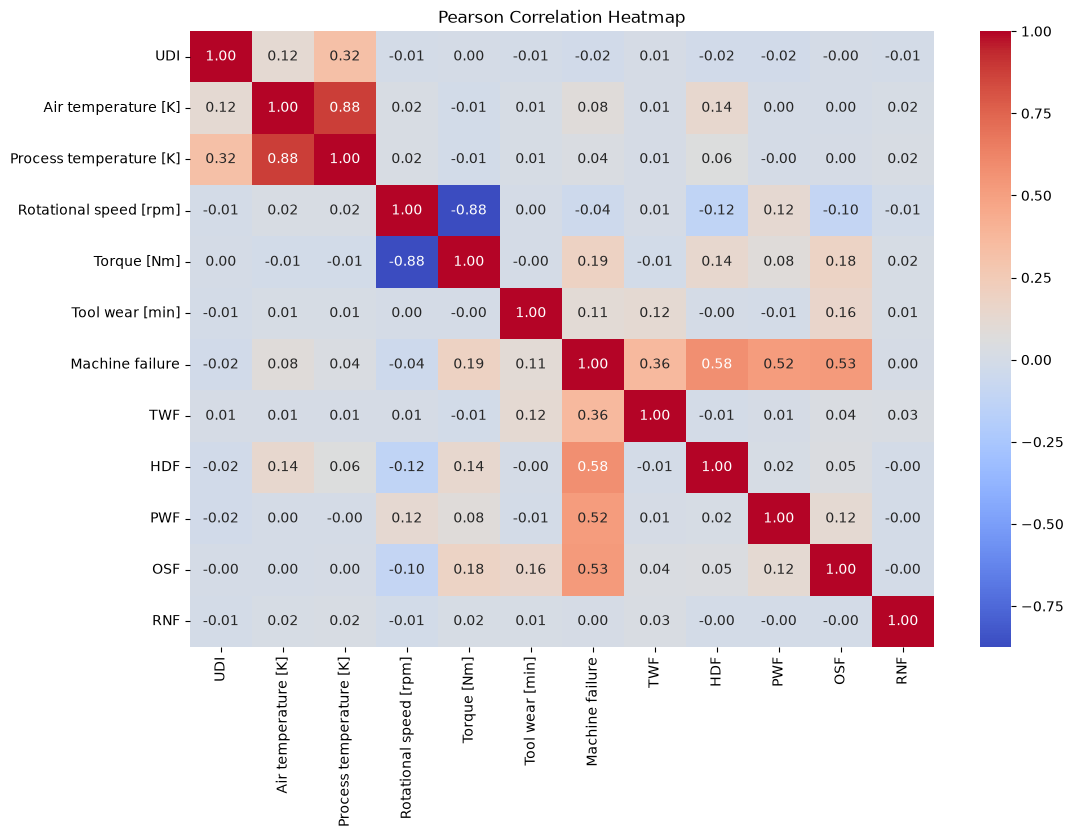

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ai4i2020.csv")

numeric_df = df.select_dtypes(include=["int64", "float64"])

pearson_corr = numeric_df.corr(method="pearson")

plt.figure(figsize=(12, 8))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Pearson Correlation Heatmap")
plt.show()

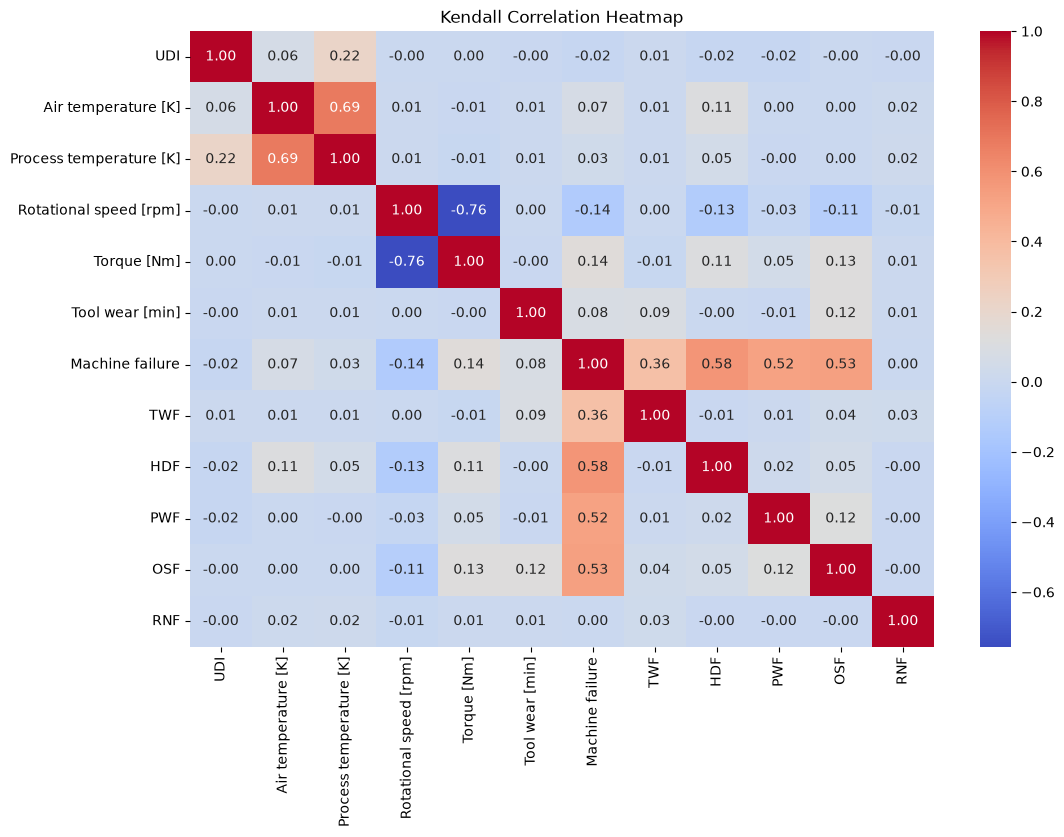

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("ai4i2020.csv")

# Select only numerical columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Calculate Kendall correlation
kendall_corr = numeric_df.corr(method="kendall")

# Create heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    kendall_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Kendall Correlation Heatmap")
plt.show()

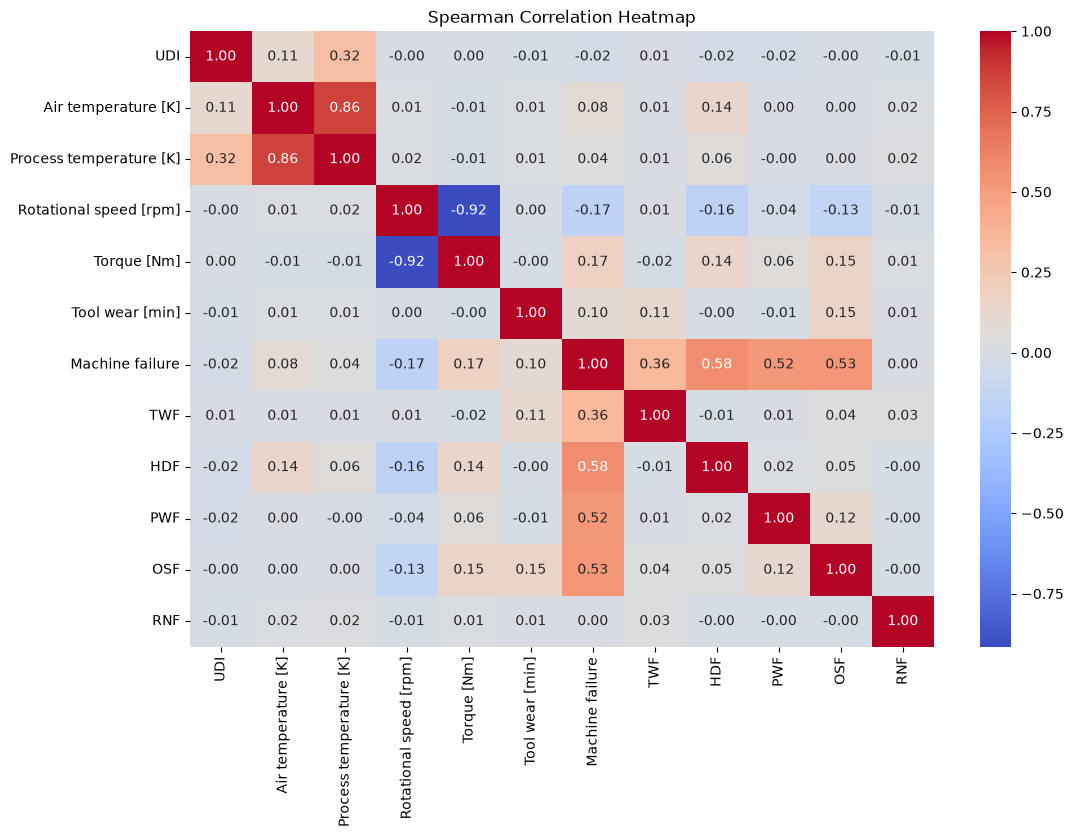

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("ai4i2020.csv")

# Select only numerical columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Calculate Spearman correlation
spearman_corr = numeric_df.corr(method="spearman")

# Create heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Spearman Correlation Heatmap")
plt.show()

In [9]:
ark

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [10]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [11]:
df["Temperature difference"] = (
    df["Process temperature [K]"]
    - df["Air temperature [K]"]
)

In [12]:
import numpy as np
df["Power [W]"] = (
    df["Torque [Nm]"]
    * df["Rotational speed [rpm]"]
    * 2
    * np.pi
    / 60
)

In [13]:
df.drop("Product ID", axis=1, inplace=True)
df.drop("UDI", axis=1, inplace=True)

In [14]:
df = pd.get_dummies(df, columns=["Type"], dtype=int)

In [15]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split, GridSearchCV


leakage_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
leakage_cols = [c for c in leakage_cols if c in df.columns]

X = df.drop(columns=leakage_cols + ['Machine failure'])
y = df['Machine failure']

# Fix: clean column names for XGBoost compatibility
X.columns = [re.sub(r'[\[\]<>]', '', c).strip() for c in X.columns]

print("Features used:", X.columns.tolist())

Features used: ['Air temperature K', 'Process temperature K', 'Rotational speed rpm', 'Torque Nm', 'Tool wear min', 'Temperature difference', 'Power W', 'Type_H', 'Type_L', 'Type_M']


In [16]:
feature_columns = [
    "Air temperature K",
    "Process temperature K",
    "Rotational speed rpm",
    "Torque Nm",
    "Tool wear min",
    "Temperature difference",
    "Power W",
    "Type_H",
    "Type_L",
    "Type_M"
]

import re
df.columns = [re.sub(r'[\[\]<>]', '', c).strip() for c in df.columns]

X = df[feature_columns]
y = df["Machine failure"]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
df

,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Machine failure,TWF,HDF,PWF,OSF,RNF,Temperature difference,Power W,Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,6951.590560,0,0,1
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,6826.722724,0,1,0
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,7749.387543,0,1,0
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,5927.504659,0,1,0
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,5897.816608,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,298.8,308.4,1604,29.5,14,0,0,0,0,0,0,9.6,4955.129373,0,0,1
9996,298.9,308.4,1632,31.8,17,0,0,0,0,0,0,9.5,5434.703963,1,0,0
9997,299.0,308.6,1645,33.4,22,0,0,0,0,0,0,9.6,5753.617506,0,0,1
9998,299.0,308.7,1408,48.5,25,0,0,0,0,0,0,9.7,7151.102638,1,0,0


Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'scale_pos_weight': 1, 'subsample': 1.0}
Best CV F1 Score: 0.8182651641146222

Confusion Matrix:
[[1927    5]
 [  16   52]]


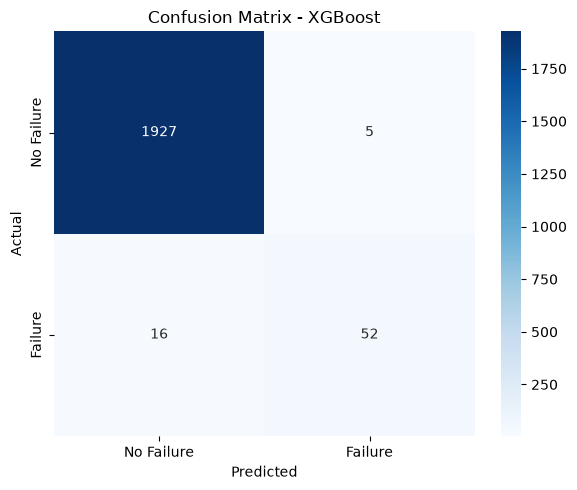


Accuracy:  0.9895
Precision: 0.9123
Recall:    0.7647
F1 Score:  0.8320

Full Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      1932
     Failure       0.91      0.76      0.83        68

    accuracy                           0.99      2000
   macro avg       0.95      0.88      0.91      2000
weighted avg       0.99      0.99      0.99      2000


Feature Importance:
 Power W                   0.209136
Temperature difference    0.195445
Rotational speed rpm      0.165471
Tool wear min             0.127046
Torque Nm                 0.120446
Type_L                    0.057994
Type_M                    0.048348
Process temperature K     0.031574
Air temperature K         0.029321
Type_H                    0.015220
dtype: float32


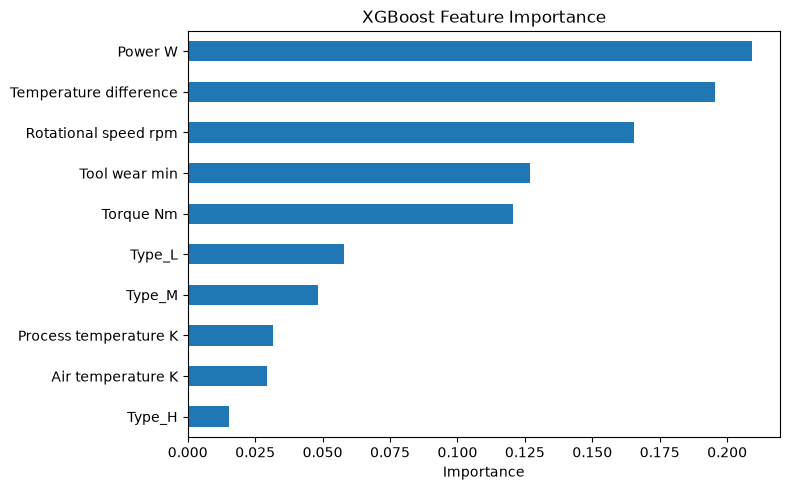

In [18]:
import xgboost as xgb
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

# ---- XGBoost + GridSearchCV ----
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'scale_pos_weight': [1, (y_train == 0).sum() / (y_train == 1).sum()]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("\nBest Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

# ---- Predict with best model ----
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

# ---- Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ---- Scores ----
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Failure', 'Failure']))

# ---- Feature Importance ----
importance = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importance:\n", importance)

plt.figure(figsize=(8, 5))
importance.plot(kind='barh')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [19]:
import joblib

joblib.dump(
    best_model,
    "machine_failure_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

feature_columns = X.columns.tolist()

joblib.dump(
    feature_columns,
    "feature_columns.pkl"
)

print("Files saved successfully")

Files saved successfully


In [20]:
print(feature_columns)

['Air temperature K', 'Process temperature K', 'Rotational speed rpm', 'Torque Nm', 'Tool wear min', 'Temperature difference', 'Power W', 'Type_H', 'Type_L', 'Type_M']


In [21]:
df.to_csv("processed_machine_data.csv", index=False)